In [1]:
import numpy as np
from scipy.special import ellipk, ellipe

def helmholtz(I1, I2, R=0.05, N=100, mesh_density=100, z_extent=1.0, r_extent=1.0):
    """
    Compute the magnetic field of two coaxial circular coils using
    the exact off-axis solution (complete elliptic integrals).

    Parameters
    ----------
    I1 : float
        Current in coil 1 (at z = +d/2), in amps.
    I2 : float
        Current in coil 2 (at z = -d/2), in amps.
        For anti-Helmholtz, pass -I1.
    R : float
        Coil radius in meters. Separation d = R.
    N : int
        Number of turns per coil.
    mesh_density : int
        Number of grid points along each axis.
    z_extent : float
        Mesh spans z in [-z_extent * R, +z_extent * R].
    r_extent : float
        Mesh spans r in [0, r_extent * R].

    Returns
    -------
    dict with keys:
        'r', 'z'       : 1D arrays (m)
        'R_mesh', 'Z_mesh' : 2D meshgrids
        'Br', 'Bz'     : 2D field components (T)
        'Bmag'          : 2D |B| (T)
        'R', 'd', 'I1', 'I2', 'N' : parameters
    """
    mu0 = 4 * np.pi * 1e-7
    d = R

    z1 = d / 2.0
    z2 = -d / 2.0

    r_arr = np.linspace(0, r_extent * R, mesh_density)
    z_arr = np.linspace(-z_extent * R, z_extent * R, mesh_density)
    R_mesh, Z_mesh = np.meshgrid(r_arr, z_arr, indexing='ij')

    def single_coil_field(I, z_coil, r_grid, z_grid):
        rho = r_grid
        dz = z_grid - z_coil
        alpha2 = R**2 + rho**2 + dz**2 - 2.0 * R * rho
        beta2 = R**2 + rho**2 + dz**2 + 2.0 * R * rho
        beta = np.sqrt(beta2)

        k2 = 1.0 - alpha2 / beta2
        k2 = np.clip(k2, 0.0, 1.0 - 1e-15)

        K = ellipk(k2)
        E = ellipe(k2)

        C = (mu0 * N * I) / (2.0 * np.pi)

        # Mask singularities: points on the wire where alpha2 ~ 0
        singular = alpha2 < 1e-30
        alpha2_safe = np.where(singular, 1.0, alpha2)
        beta_safe = np.where(singular, 1.0, beta)
        rho_safe = np.where(rho < 1e-15, 1.0, rho)

        Bz = (C / (alpha2_safe * beta_safe)) * (
            (R**2 - rho**2 - dz**2) * E + alpha2_safe * K
        )
        Bz = np.where(singular, 0.0, Bz)

        Br = (C * dz / (rho_safe * alpha2_safe * beta_safe)) * (
            (R**2 + rho**2 + dz**2) * E - alpha2_safe * K
        )
        Br = np.where(singular, 0.0, Br)
        # Br = 0 on axis by symmetry
        Br = np.where(rho < 1e-15, 0.0, Br)

        return Br, Bz

    Br1, Bz1 = single_coil_field(I1, z1, R_mesh, Z_mesh)
    Br2, Bz2 = single_coil_field(I2, z2, R_mesh, Z_mesh)

    Br = Br1 + Br2
    Bz = Bz1 + Bz2
    Bmag = np.sqrt(Br**2 + Bz**2)

    return {
        'r': r_arr, 'z': z_arr,
        'R_mesh': R_mesh, 'Z_mesh': Z_mesh,
        'Br': Br, 'Bz': Bz, 'Bmag': Bmag,
        'R': R, 'd': d, 'I1': I1, 'I2': I2, 'N': N,
    }



In [19]:
import matplotlib.pyplot as plt
%matplotlib widget

I = 1.0
res = helmholtz(I1=I, I2=I, R=0.81, N=20, mesh_density=200, z_extent=0.9, r_extent=0.1)

r = res['r']
z = res['z']
Rm = res['R_mesh'] * 1e3   # mm
Zm = res['Z_mesh'] * 1e3
Br = res['Br']
Bz = res['Bz']
Bmag = res['Bmag']
R = res['R']
d = res['d']
Bmag_G = Bmag * 1e4  # Gauss

coil_z_mm = [d/2*1e3, -d/2*1e3]
coil_r_mm = R * 1e3

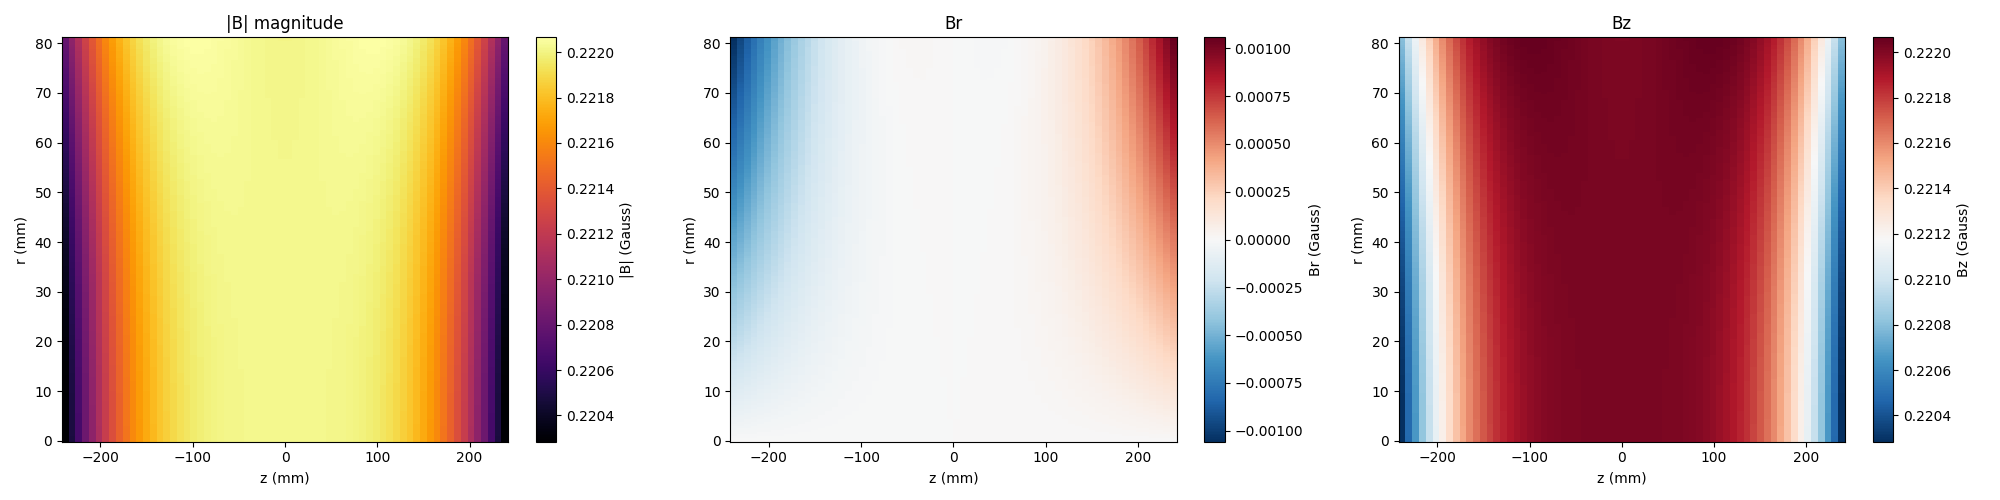

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

frac = 0.3
r_mask = r <= frac * R
z_mask = np.abs(z) <= frac * R

ri = np.where(r_mask)[0]
zi = np.where(z_mask)[0]

Zm_c = Zm[np.ix_(ri, zi)]
Rm_c = Rm[np.ix_(ri, zi)]

# |B|
ax = axes[0]
pcm = ax.pcolormesh(Zm_c.T, Rm_c.T, Bmag_G[np.ix_(ri, zi)].T, shading='auto', cmap='inferno')
fig.colorbar(pcm, ax=ax, label='|B| (Gauss)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('|B| magnitude')

# Br
ax = axes[1]
pcm = ax.pcolormesh(Zm_c.T, Rm_c.T, Br[np.ix_(ri, zi)].T * 1e4, shading='auto', cmap='RdBu_r')
fig.colorbar(pcm, ax=ax, label='Br (Gauss)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Br')

# Bz
ax = axes[2]
pcm = ax.pcolormesh(Zm_c.T, Rm_c.T, Bz[np.ix_(ri, zi)].T * 1e4, shading='auto', cmap='RdBu_r')
fig.colorbar(pcm, ax=ax, label='Bz (Gauss)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Bz')

fig.tight_layout()
plt.show()

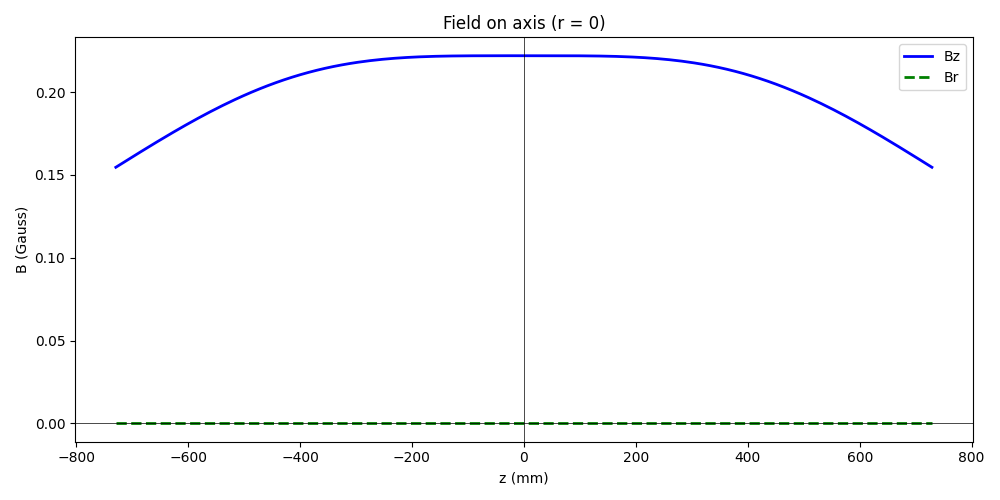

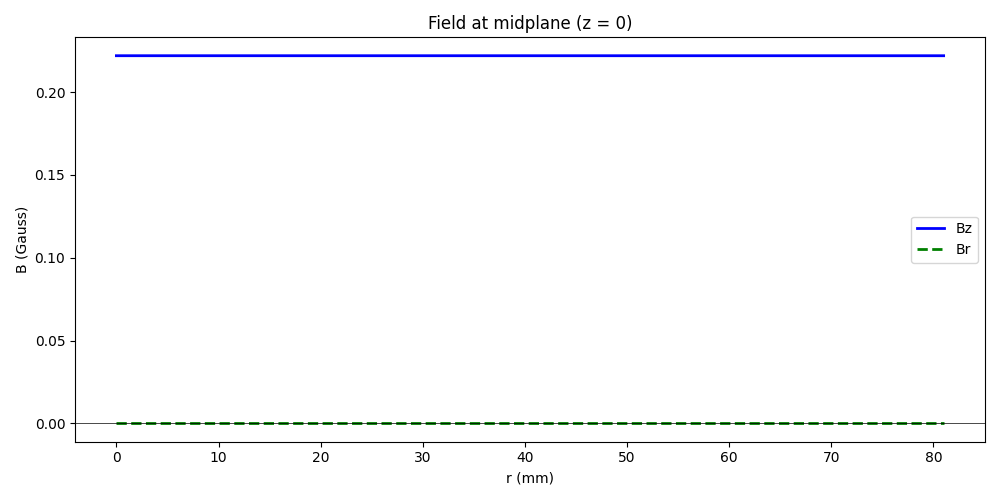

In [21]:
plt.figure(figsize=(10, 5))

Bz_axis = Bz[0, :] * 1e4
Br_axis = Br[0, :] * 1e4

plt.plot(z * 1e3, Bz_axis, 'b-', linewidth=2, label='Bz')
plt.plot(z * 1e3, Br_axis, 'g--', linewidth=2, label='Br')
plt.axhline(0, color='k', linewidth=0.5)
plt.axvline(0, color='k', linewidth=0.5)
plt.xlabel('z (mm)')
plt.ylabel('B (Gauss)')
plt.title('Field on axis (r = 0)')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

z_ci = np.argmin(np.abs(z))

Bz_radial = Bz[:, z_ci] * 1e4
Br_radial = Br[:, z_ci] * 1e4

plt.plot(r * 1e3, Bz_radial, 'b-', linewidth=2, label='Bz')
plt.plot(r * 1e3, Br_radial, 'g--', linewidth=2, label='Br')
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel('r (mm)')
plt.ylabel('B (Gauss)')
plt.title('Field at midplane (z = 0)')
plt.legend()
plt.tight_layout()
plt.show()



[7.   7.25 7.5  7.75 8.   8.25 8.5  8.75 9.  ]


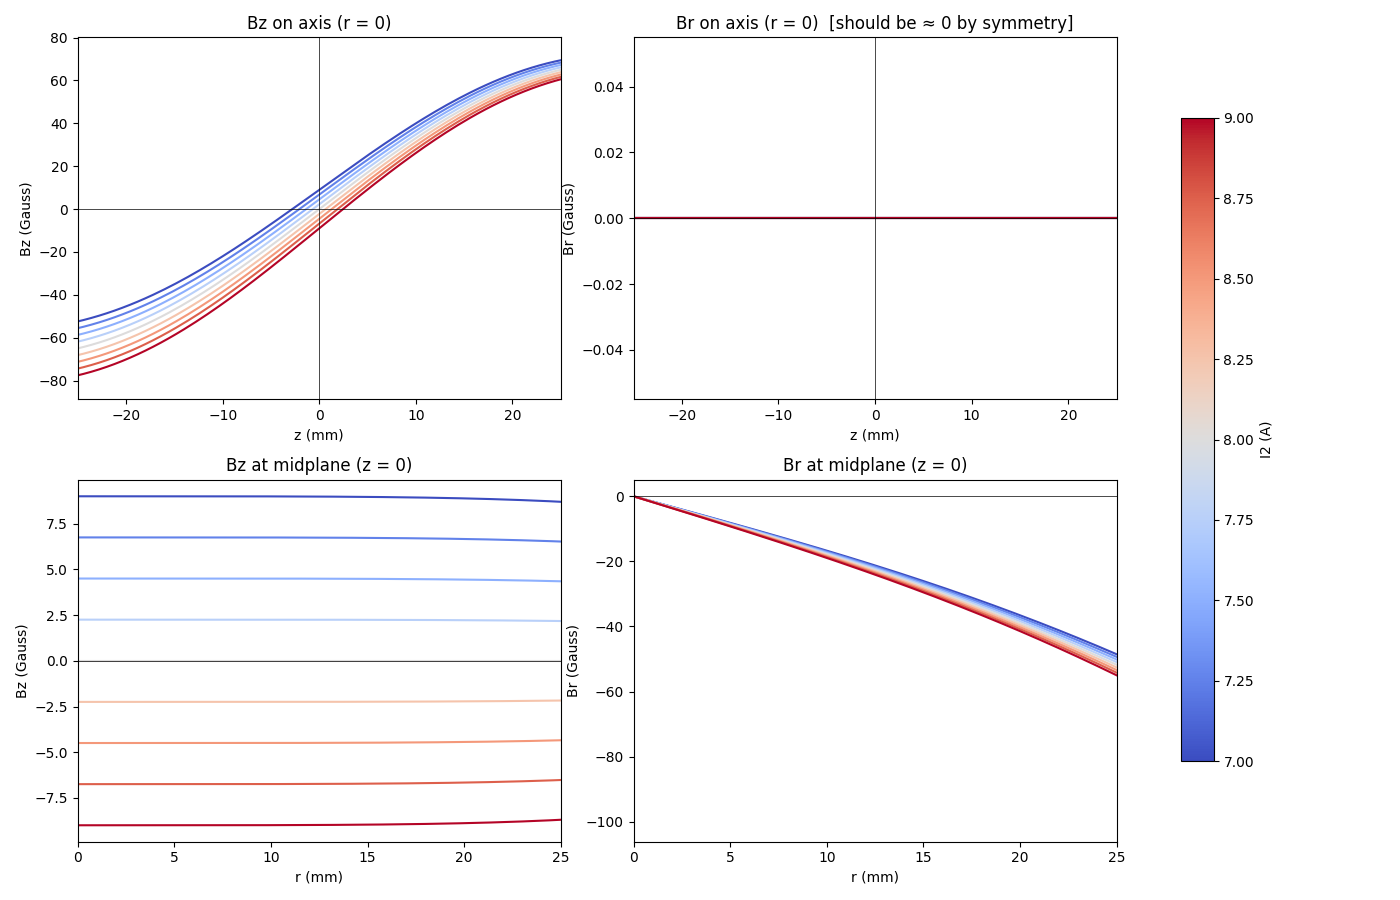

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

I1 = 8
I2_arr = np.arange(7,9.25,.25)
print(I2_arr)
colors = plt.cm.coolwarm(np.linspace(0, 1, len(I2_arr)))

zoom = 0.5

results = []
for I2 in I2_arr:
    results.append(helmholtz(I1=I1, I2=-I2, R=0.05, N=100, mesh_density=201, z_extent=0.8, r_extent=0.8))

z_lim = zoom * results[0]['R'] * 1e3
r_lim = zoom * results[0]['R'] * 1e3

# Top left: Bz along z (r = 0)
ax = axes[0, 0]
for i, res in enumerate(results):
    ax.plot(res['z'] * 1e3, res['Bz'][0, :] * 1e4, '-', color=colors[i], linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlim(-z_lim, z_lim)
ax.set_xlabel('z (mm)')
ax.set_ylabel('Bz (Gauss)')
ax.set_title('Bz on axis (r = 0)')

# Top right: Br along z (r = 0)
ax = axes[0, 1]
for i, res in enumerate(results):
    ax.plot(res['z'] * 1e3, res['Br'][0, :] * 1e4, '-', color=colors[i], linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.axvline(0, color='k', linewidth=0.5)
ax.set_xlim(-z_lim, z_lim)
ax.set_xlabel('z (mm)')
ax.set_ylabel('Br (Gauss)')
ax.set_title('Br on axis (r = 0)  [should be ≈ 0 by symmetry]')

# Bottom left: Bz along r (z = 0)
ax = axes[1, 0]
for i, res in enumerate(results):
    z_center = np.argmin(np.abs(res['z']))
    ax.plot(res['r'] * 1e3, res['Bz'][:, z_center] * 1e4, '-', color=colors[i], linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlim(0, r_lim)
ax.set_xlabel('r (mm)')
ax.set_ylabel('Bz (Gauss)')
ax.set_title('Bz at midplane (z = 0)')

# Bottom right: Br along r (z = 0)
ax = axes[1, 1]
for i, res in enumerate(results):
    z_center = np.argmin(np.abs(res['z']))
    ax.plot(res['r'] * 1e3, res['Br'][:, z_center] * 1e4, '-', color=colors[i], linewidth=1.5)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlim(0, r_lim)
ax.set_xlabel('r (mm)')
ax.set_ylabel('Br (Gauss)')
ax.set_title('Br at midplane (z = 0)')

fig.tight_layout()

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(I2_arr[0], I2_arr[-1]))
fig.colorbar(sm, ax=axes.ravel().tolist(), label='I2 (A)', shrink=0.8)

plt.show()

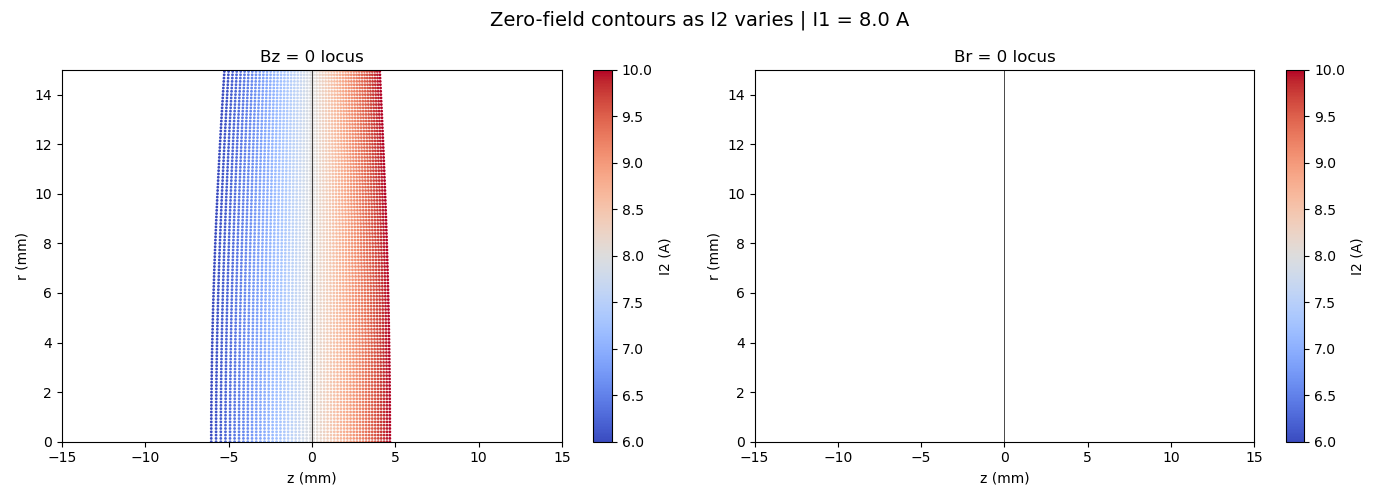

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

I1 = 8.0
I2_arr = np.linspace(6, 10, 50)
I2_arr = np.union1d(I2_arr, [I1])

Bz_zero_r = []
Bz_zero_z = []
Br_zero_r = []
Br_zero_z = []

for I2 in I2_arr:
    res = helmholtz(I1=I1, I2=-I2, R=0.05, N=100, mesh_density=301, z_extent=0.8, r_extent=0.8)
    
    # Find Bz = 0 contour: for each r, find z where Bz crosses zero
    for ri in range(len(res['r'])):
        Bz_line = res['Bz'][ri, :]
        sign_changes = np.where(np.diff(np.sign(Bz_line)))[0]
        for sc in sign_changes:
            # Linear interpolation
            z0 = res['z'][sc] - Bz_line[sc] * (res['z'][sc+1] - res['z'][sc]) / (Bz_line[sc+1] - Bz_line[sc])
            Bz_zero_r.append(res['r'][ri] * 1e3)
            Bz_zero_z.append(z0 * 1e3)
    
    # Find Br = 0 contour: for each z, find r where Br crosses zero (skip r=0 trivial)
    for zi in range(len(res['z'])):
        Br_line = res['Br'][1:, zi]  # skip r=0
        r_line = res['r'][1:]
        sign_changes = np.where(np.diff(np.sign(Br_line)))[0]
        for sc in sign_changes:
            r0 = r_line[sc] - Br_line[sc] * (r_line[sc+1] - r_line[sc]) / (Br_line[sc+1] - Br_line[sc])
            Br_zero_r.append(r0 * 1e3)
            Br_zero_z.append(res['z'][zi] * 1e3)

# Oops — that loses the I2 information. Redo with I2 tracked.

Bz_zeros = {'I2': [], 'r': [], 'z': []}
Br_zeros = {'I2': [], 'r': [], 'z': []}

for I2 in I2_arr:
    res = helmholtz(I1=I1, I2=-I2, R=0.05, N=100, mesh_density=301, z_extent=0.8, r_extent=0.8)
    
    for ri in range(len(res['r'])):
        Bz_line = res['Bz'][ri, :]
        sign_changes = np.where(np.diff(np.sign(Bz_line)))[0]
        for sc in sign_changes:
            z0 = res['z'][sc] - Bz_line[sc] * (res['z'][sc+1] - res['z'][sc]) / (Bz_line[sc+1] - Bz_line[sc])
            Bz_zeros['I2'].append(I2)
            Bz_zeros['r'].append(res['r'][ri] * 1e3)
            Bz_zeros['z'].append(z0 * 1e3)
    
    for zi in range(len(res['z'])):
        Br_line = res['Br'][1:, zi]
        r_line = res['r'][1:]
        sign_changes = np.where(np.diff(np.sign(Br_line)))[0]
        for sc in sign_changes:
            r0 = r_line[sc] - Br_line[sc] * (r_line[sc+1] - r_line[sc]) / (Br_line[sc+1] - Br_line[sc])
            Br_zeros['I2'].append(I2)
            Br_zeros['r'].append(r0 * 1e3)
            Br_zeros['z'].append(res['z'][zi] * 1e3)

for key in Bz_zeros:
    Bz_zeros[key] = np.array(Bz_zeros[key])
for key in Br_zeros:
    Br_zeros[key] = np.array(Br_zeros[key])

# Left: Bz = 0 contours in (z, r) plane, colored by I2
ax = axes[0]
sc = ax.scatter(Bz_zeros['z'], Bz_zeros['r'], c=Bz_zeros['I2'], cmap='coolwarm',
                s=1, vmin=I2_arr[0], vmax=I2_arr[-1])
fig.colorbar(sc, ax=ax, label='I2 (A)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Bz = 0 locus')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 15)
ax.axvline(0, color='k', linewidth=0.5)

# Right: Br = 0 contours in (z, r) plane, colored by I2
ax = axes[1]
sc = ax.scatter(Br_zeros['z'], Br_zeros['r'], c=Br_zeros['I2'], cmap='coolwarm',
                s=1, vmin=I2_arr[0], vmax=I2_arr[-1])
fig.colorbar(sc, ax=ax, label='I2 (A)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Br = 0 locus')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 15)
ax.axvline(0, color='k', linewidth=0.5)

fig.suptitle(f'Zero-field contours as I2 varies | I1 = {I1} A', fontsize=14)
fig.tight_layout()
plt.show()

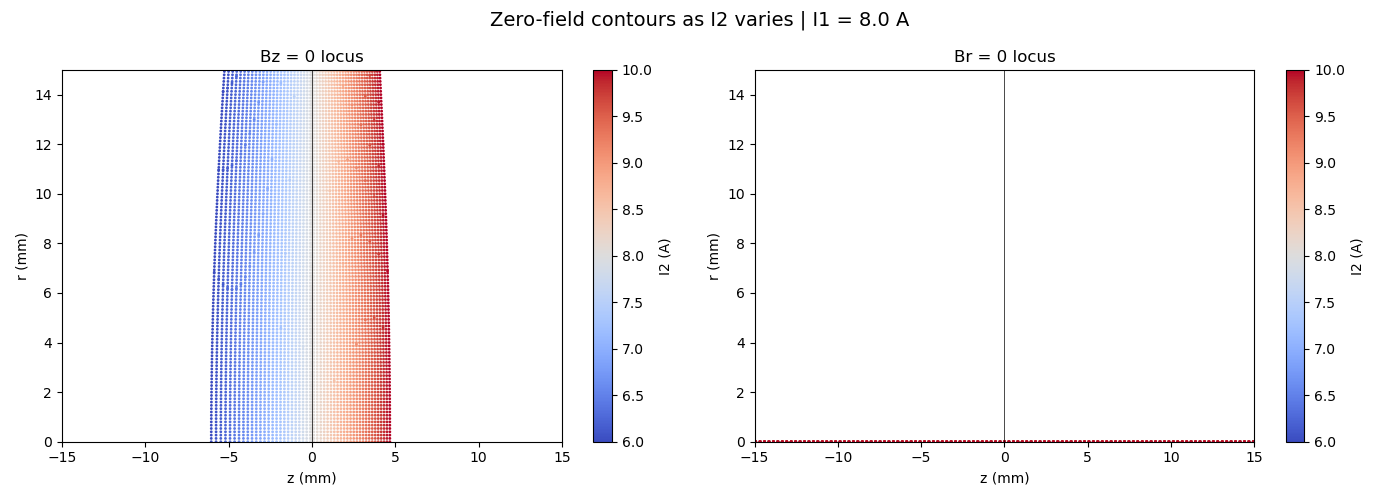

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

I1 = 8.0
I2_arr = np.linspace(6, 10, 50)
I2_arr = np.union1d(I2_arr, [I1])

Bz_zeros = {'I2': [], 'r': [], 'z': []}
Br_zeros = {'I2': [], 'r': [], 'z': []}

for I2 in I2_arr:
    res = helmholtz(I1=I1, I2=-I2, R=0.05, N=100, mesh_density=301, z_extent=0.8, r_extent=0.8)
    
    # Scan along z for each r
    for ri in range(len(res['r'])):
        Bz_line = res['Bz'][ri, :]
        for sc in np.where(np.diff(np.sign(Bz_line)))[0]:
            z0 = res['z'][sc] - Bz_line[sc] * (res['z'][sc+1] - res['z'][sc]) / (Bz_line[sc+1] - Bz_line[sc])
            Bz_zeros['I2'].append(I2)
            Bz_zeros['r'].append(res['r'][ri] * 1e3)
            Bz_zeros['z'].append(z0 * 1e3)

        Br_line = res['Br'][ri, :]
        for sc in np.where(np.diff(np.sign(Br_line)))[0]:
            z0 = res['z'][sc] - Br_line[sc] * (res['z'][sc+1] - res['z'][sc]) / (Br_line[sc+1] - Br_line[sc])
            Br_zeros['I2'].append(I2)
            Br_zeros['r'].append(res['r'][ri] * 1e3)
            Br_zeros['z'].append(z0 * 1e3)

    # Scan along r for each z
    for zi in range(len(res['z'])):
        Bz_line = res['Bz'][:, zi]
        for sc in np.where(np.diff(np.sign(Bz_line)))[0]:
            r0 = res['r'][sc] - Bz_line[sc] * (res['r'][sc+1] - res['r'][sc]) / (Bz_line[sc+1] - Bz_line[sc])
            Bz_zeros['I2'].append(I2)
            Bz_zeros['r'].append(r0 * 1e3)
            Bz_zeros['z'].append(res['z'][zi] * 1e3)

        Br_line = res['Br'][:, zi]
        for sc in np.where(np.diff(np.sign(Br_line)))[0]:
            r0 = res['r'][sc] - Br_line[sc] * (res['r'][sc+1] - res['r'][sc]) / (Br_line[sc+1] - Br_line[sc])
            Br_zeros['I2'].append(I2)
            Br_zeros['r'].append(r0 * 1e3)
            Br_zeros['z'].append(res['z'][zi] * 1e3)

for d in [Bz_zeros, Br_zeros]:
    for key in d:
        d[key] = np.array(d[key])

# Left: Bz = 0
ax = axes[0]
sc = ax.scatter(Bz_zeros['z'], Bz_zeros['r'], c=Bz_zeros['I2'], cmap='coolwarm',
                s=1, vmin=I2_arr[0], vmax=I2_arr[-1])
fig.colorbar(sc, ax=ax, label='I2 (A)')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Bz = 0 locus')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 15)
ax.axvline(0, color='k', linewidth=0.5)

# Right: Br = 0
ax = axes[1]
if len(Br_zeros['z']) > 0:
    sc = ax.scatter(Br_zeros['z'], Br_zeros['r'], c=Br_zeros['I2'], cmap='coolwarm',
                    s=1, vmin=I2_arr[0], vmax=I2_arr[-1])
    fig.colorbar(sc, ax=ax, label='I2 (A)')
else:
    ax.text(0.5, 0.5, 'No Br = 0 crossings found', transform=ax.transAxes, ha='center')
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Br = 0 locus')
ax.set_xlim(-15, 15)
ax.set_ylim(0, 15)
ax.axvline(0, color='k', linewidth=0.5)

fig.suptitle(f'Zero-field contours as I2 varies | I1 = {I1} A', fontsize=14)
fig.tight_layout()
plt.show()

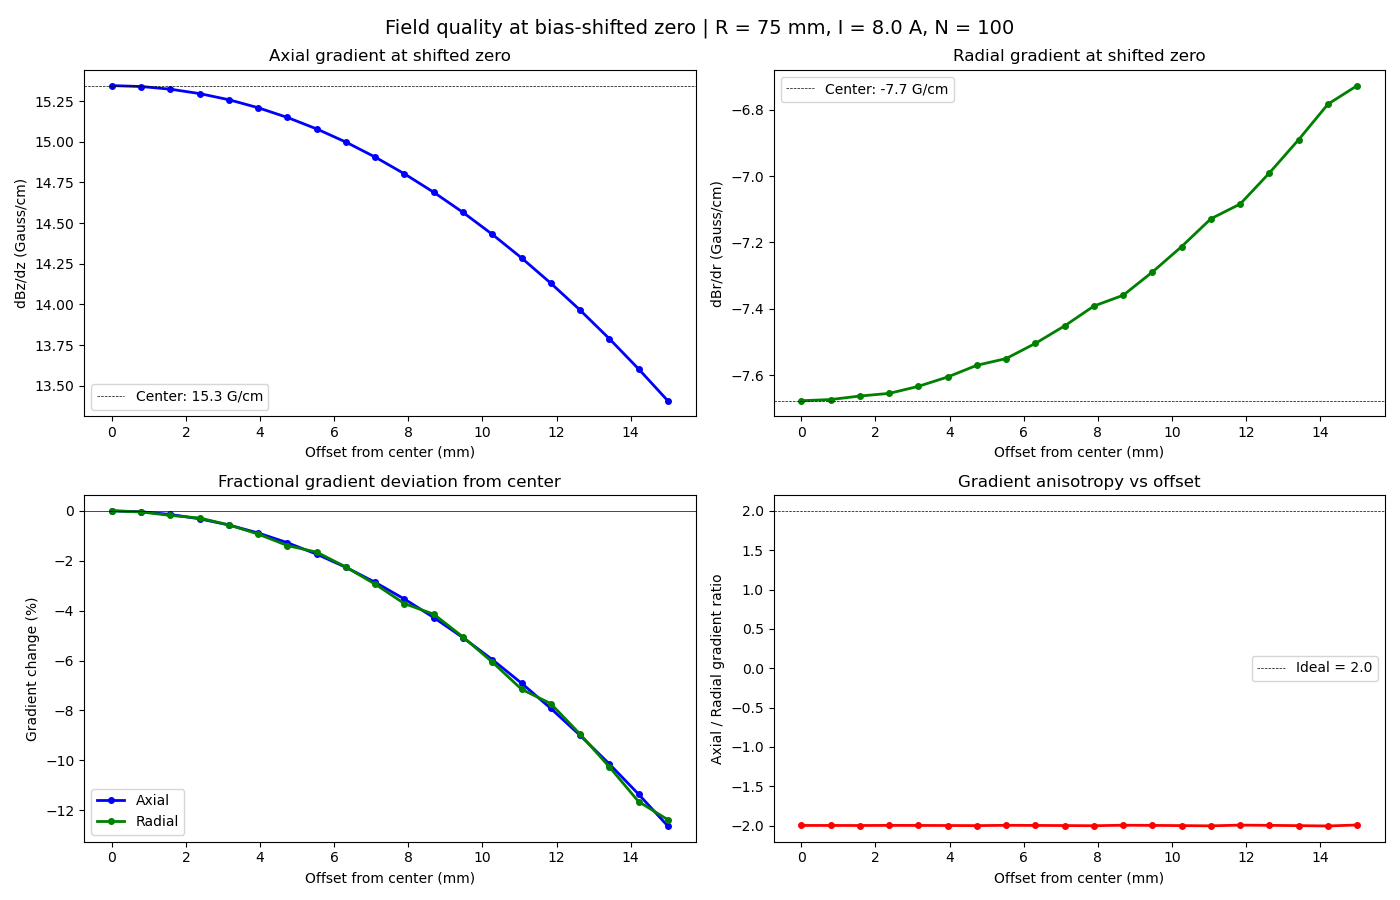


Center axial gradient: 15.35 G/cm
Center radial gradient: -7.68 G/cm
Center ratio: -1.999 (ideal = 2.000)

At 15 mm offset:
  Axial gradient changed by -12.6%
  Radial gradient changed by -12.4%
  Ratio: -1.993


In [91]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

I1 = 8.0
R = 0.075
N = 100

# Offsets to test: shift the field zero by adding a bias field
# We'll look at the field along z through the shifted zero
offsets_mm = np.linspace(0, 15, 20)  # mm offset along z
offsets_m = offsets_mm * 1e-3

res = helmholtz(I1=I1, I2=-I1, R=R, N=N, mesh_density=501, z_extent=1.5, r_extent=1.5)

# On-axis field: Bz(r=0, z)
Bz_axis = res['Bz'][0, :]
z = res['z']
dz = z[1] - z[0]

# For each offset, add a uniform Bz bias that shifts the zero to that offset
# At the center, Bz = 0. At offset z0, Bz_AH(z0) = some value.
# We need bias = -Bz_AH(z0) to make the total field zero at z0.

colors = plt.cm.viridis(np.linspace(0, 1, len(offsets_m)))

gradients_z = []
gradients_r = []
curvatures_z = []
curvatures_r = []

for j, z0 in enumerate(offsets_m):
    # Find bias field needed to shift zero to z0
    Bz_at_z0 = np.interp(z0, z, Bz_axis)
    bias = -Bz_at_z0

    # Shifted on-axis field
    Bz_shifted = Bz_axis + bias

    # Gradient at new zero: dBz/dz at z = z0
    dBz_dz = np.gradient(Bz_axis, dz)
    grad_at_z0 = np.interp(z0, z, dBz_dz)
    gradients_z.append(grad_at_z0 * 1e-2)  # Gauss/cm

    # Curvature at new zero: d2Bz/dz2 at z = z0
    d2Bz_dz2 = np.gradient(dBz_dz, dz)
    curv_at_z0 = np.interp(z0, z, d2Bz_dz2)
    curvatures_z.append(curv_at_z0 * 1e-2 * 1e-3)  # Gauss/cm^2 ... let's keep raw and label

    # Radial gradient at the shifted zero
    # Br(r, z=z0) — find the z index closest to z0
    zi = np.argmin(np.abs(z - z0))
    Br_radial = res['Br'][:, zi]
    r_arr = res['r']
    dr = r_arr[1] - r_arr[0]
    dBr_dr = np.gradient(Br_radial, dr)
    # Radial gradient near r = 0
    ri_center = min(5, len(r_arr) - 1)  # a few points off axis to avoid r=0 noise
    gradients_r.append(dBr_dr[ri_center] * 1e-2)

    # Radial curvature
    d2Br_dr2 = np.gradient(dBr_dr, dr)
    curvatures_r.append(d2Br_dr2[ri_center] * 1e-2 * 1e-3)

gradients_z = np.array(gradients_z) * 1e4   # T/m -> Gauss/cm conversion fix
gradients_r = np.array(gradients_r) * 1e4
curvatures_z = np.array(curvatures_z) * 1e4
curvatures_r = np.array(curvatures_r) * 1e4

# Normalize to center values for easy comparison
grad_z_center = gradients_z[0]
grad_r_center = gradients_r[0]

# Top left: axial gradient vs offset
ax = axes[0, 0]
ax.plot(offsets_mm, gradients_z, 'b-o', linewidth=2, markersize=4)
ax.axhline(grad_z_center, color='k', linewidth=0.5, linestyle='--', label=f'Center: {grad_z_center:.1f} G/cm')
ax.set_xlabel('Offset from center (mm)')
ax.set_ylabel('dBz/dz (Gauss/cm)')
ax.set_title('Axial gradient at shifted zero')
ax.legend()

# Top right: radial gradient vs offset
ax = axes[0, 1]
ax.plot(offsets_mm, gradients_r, 'g-o', linewidth=2, markersize=4)
ax.axhline(grad_r_center, color='k', linewidth=0.5, linestyle='--', label=f'Center: {grad_r_center:.1f} G/cm')
ax.set_xlabel('Offset from center (mm)')
ax.set_ylabel('dBr/dr (Gauss/cm)')
ax.set_title('Radial gradient at shifted zero')
ax.legend()

# Bottom left: fractional gradient change
ax = axes[1, 0]
ax.plot(offsets_mm, (gradients_z / grad_z_center - 1) * 100, 'b-o', linewidth=2, markersize=4, label='Axial')
ax.plot(offsets_mm, (gradients_r / grad_r_center - 1) * 100, 'g-o', linewidth=2, markersize=4, label='Radial')
ax.set_xlabel('Offset from center (mm)')
ax.set_ylabel('Gradient change (%)')
ax.set_title('Fractional gradient deviation from center')
ax.legend()
ax.axhline(0, color='k', linewidth=0.5)

# Bottom right: ratio of axial to radial gradient (should be 2:1 at center)
ax = axes[1, 1]
ratio = gradients_z / gradients_r
ax.plot(offsets_mm, ratio, 'r-o', linewidth=2, markersize=4)
ax.axhline(2.0, color='k', linewidth=0.5, linestyle='--', label='Ideal = 2.0')
ax.set_xlabel('Offset from center (mm)')
ax.set_ylabel('Axial / Radial gradient ratio')
ax.set_title('Gradient anisotropy vs offset')
ax.legend()

fig.suptitle(f'Field quality at bias-shifted zero | R = {R*1e3:.0f} mm, I = {I1} A, N = {N}', fontsize=14)
fig.tight_layout()
plt.show()

print(f"\nCenter axial gradient: {grad_z_center:.2f} G/cm")
print(f"Center radial gradient: {grad_r_center:.2f} G/cm")
print(f"Center ratio: {grad_z_center/grad_r_center:.3f} (ideal = 2.000)")
print(f"\nAt {offsets_mm[-1]:.0f} mm offset:")
print(f"  Axial gradient changed by {(gradients_z[-1]/grad_z_center - 1)*100:.1f}%")
print(f"  Radial gradient changed by {(gradients_r[-1]/grad_r_center - 1)*100:.1f}%")
print(f"  Ratio: {ratio[-1]:.3f}")

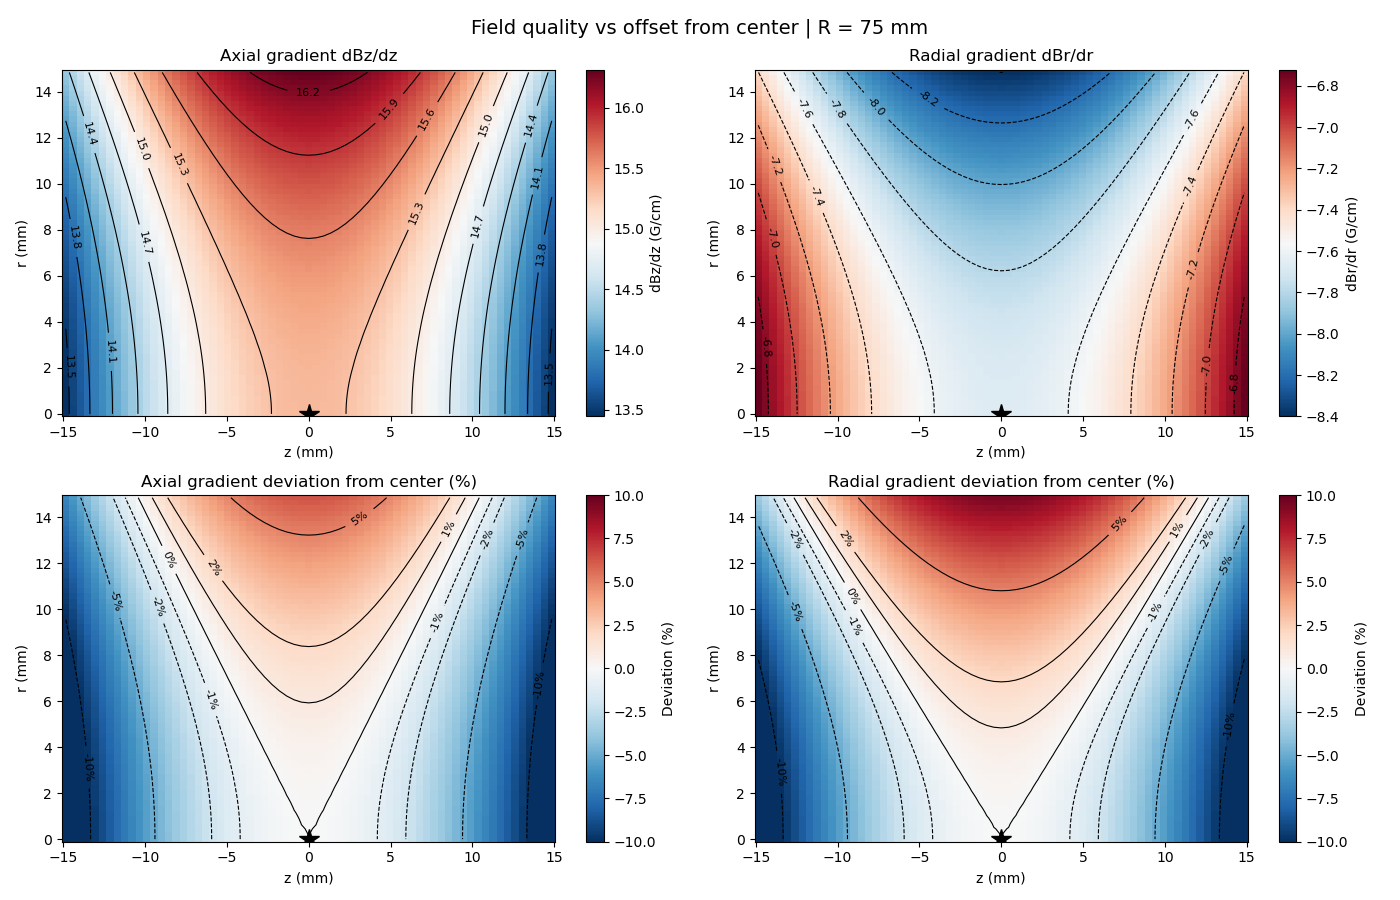

Center axial gradient: 15.35 G/cm
Center radial gradient: -7.67 G/cm
Center ratio: 2.000


In [84]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

I1 = 8.0
R = 0.075
N = 100

res = helmholtz(I1=I1, I2=-I1, R=R, N=N, mesh_density=501, z_extent=1.5, r_extent=1.5)

z = res['z']
r = res['r']
dz = z[1] - z[0]
dr = r[1] - r[0]

dBz_dz = np.gradient(res['Bz'], dz, axis=1)
dBr_dr = np.gradient(res['Br'], dr, axis=0)

dBz_dz_Gcm = dBz_dz * 1e4 * 1e-2
dBr_dr_Gcm = dBr_dr * 1e4 * 1e-2

z_ci = np.argmin(np.abs(z))
r_ci = 0
grad_z_center = dBz_dz_Gcm[r_ci, z_ci]
grad_r_center = dBr_dr_Gcm[r_ci, z_ci]

zoom = 0.2
r_mask = r <= zoom * R
z_mask = np.abs(z) <= zoom * R
ri = np.where(r_mask)[0]
zi = np.where(z_mask)[0]

Rm_mm = res['R_mesh'][np.ix_(ri, zi)] * 1e3
Zm_mm = res['Z_mesh'][np.ix_(ri, zi)] * 1e3

# Top left: dBz/dz heatmap + contours
ax = axes[0, 0]
data = dBz_dz_Gcm[np.ix_(ri, zi)]
pcm = ax.pcolormesh(Zm_mm.T, Rm_mm.T, data.T, shading='auto', cmap='RdBu_r')
fig.colorbar(pcm, ax=ax, label='dBz/dz (G/cm)')
cs = ax.contour(Zm_mm.T, Rm_mm.T, data.T, levels=10, colors='k', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
ax.plot(0, 0, 'k*', markersize=15)
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Axial gradient dBz/dz')

# Top right: dBr/dr heatmap + contours
ax = axes[0, 1]
data = dBr_dr_Gcm[np.ix_(ri, zi)]
pcm = ax.pcolormesh(Zm_mm.T, Rm_mm.T, data.T, shading='auto', cmap='RdBu_r')
fig.colorbar(pcm, ax=ax, label='dBr/dr (G/cm)')
cs = ax.contour(Zm_mm.T, Rm_mm.T, data.T, levels=10, colors='k', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.1f')
ax.plot(0, 0, 'k*', markersize=15)
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Radial gradient dBr/dr')

# Bottom left: fractional deviation of axial gradient + contours
ax = axes[1, 0]
frac_dev = (dBz_dz_Gcm[np.ix_(ri, zi)] / grad_z_center - 1) * 100
pcm = ax.pcolormesh(Zm_mm.T, Rm_mm.T, frac_dev.T, shading='auto', cmap='RdBu_r')
pcm.set_clim(-10, 10)
fig.colorbar(pcm, ax=ax, label='Deviation (%)')
contour_levels = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
cs = ax.contour(Zm_mm.T, Rm_mm.T, frac_dev.T, levels=contour_levels, colors='k', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f%%')
ax.plot(0, 0, 'k*', markersize=15)
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Axial gradient deviation from center (%)')

# Bottom right: fractional deviation of radial gradient
ax = axes[1, 1]
frac_dev_r = (dBr_dr_Gcm[np.ix_(ri, zi)] / grad_r_center - 1) * 100
pcm = ax.pcolormesh(Zm_mm.T, Rm_mm.T, frac_dev_r.T, shading='auto', cmap='RdBu_r')
pcm.set_clim(-10, 10)
fig.colorbar(pcm, ax=ax, label='Deviation (%)')
contour_levels = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
cs = ax.contour(Zm_mm.T, Rm_mm.T, frac_dev_r.T, levels=contour_levels, colors='k', linewidths=0.8)
ax.clabel(cs, inline=True, fontsize=8, fmt='%.0f%%')
ax.plot(0, 0, 'k*', markersize=15)
ax.set_xlabel('z (mm)')
ax.set_ylabel('r (mm)')
ax.set_title('Radial gradient deviation from center (%)')

fig.suptitle(f'Field quality vs offset from center | R = {R*1e3:.0f} mm', fontsize=14)
fig.tight_layout()
plt.show()

print(f"Center axial gradient: {grad_z_center:.2f} G/cm")
print(f"Center radial gradient: {grad_r_center:.2f} G/cm")
print(f"Center ratio: {-grad_z_center/grad_r_center:.3f}")